###K-Means Clustering Follow-Along, DSCI-590 Applied Data Science.  
#####Owen Randolph, 9/30/2024

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

In [3]:
# Load Dataset
dataset = pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Select the annual income and the spending score columns
X = dataset.iloc[:, [3, 4]].values

##### Find the optimal number of clusters through the elbow method

In [6]:
# Loop through k-means algorithm set to a different number of clusters and compute the within cluster sum of squares (WCSS)
# init parameter - kmeans++ method
# max_iter parameter is the maximum number of iterations we want to apply.  Default is 300
# n_init which is the number of times the # K-means algorithm will be run with different intitial centroid.

wcss=[]

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

##### Elbow Graph

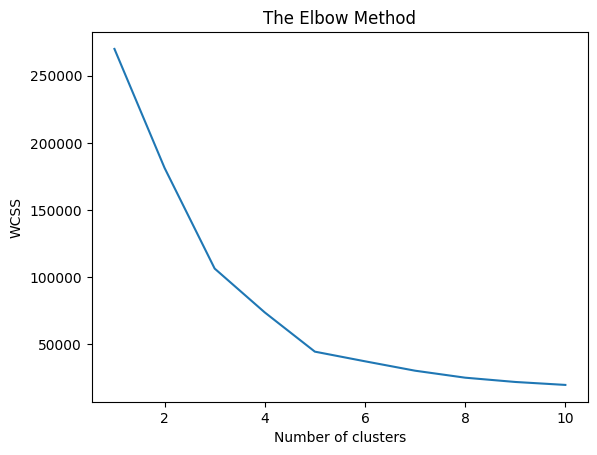

In [7]:
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

##### The point with the elbow is 5, which is out optimal number of clusters

In [8]:
# Now we can implement the best k-means algorithm
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)

In [9]:
# We can predict the number of customers
y_kmeans = kmeans.fit_predict(X)

##### Visualization - Scatter plot of clusters with centroid

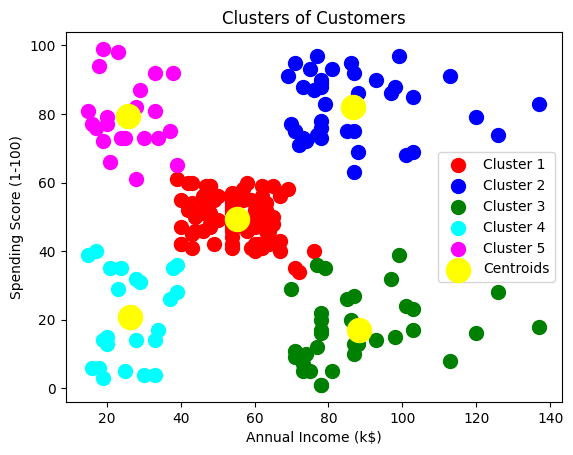

In [11]:
plt.scatter(X[y_kmeans==0, 0], X[y_kmeans==0, 1], s=100, c='red', label = 'Cluster 1')
plt.scatter(X[y_kmeans==1, 0], X[y_kmeans==1, 1], s=100, c='blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans==2, 0], X[y_kmeans==2, 1], s=100, c='green', label = 'Cluster 3')
plt.scatter(X[y_kmeans==3, 0], X[y_kmeans==3, 1], s=100, c='cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans==4, 0], X[y_kmeans==4, 1], s=100, c='magenta', label = 'Cluster 5')
# see hierarchical notebook for scatter plot axes explanation
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label = 'Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

##### The results are similar to hierarchical clustering